# Model Evaluation & Analysis

Comprehensive evaluation tools for trained FER models:
- Confusion matrix visualization
- Per-class metrics (Precision, Recall, F1-score)
- Error analysis
- Misclassification examples
- Performance comparison across experiments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, accuracy_score
)
from pathlib import Path
import json

print('All libraries imported successfully')

All libraries imported successfully


## Configuration

In [2]:
# Paths
PROJECT_ROOT = Path('/Users/nadaashraf/Desktop/FER copy')
DATA_DIR = PROJECT_ROOT / 'data' / 'fer2013'
MODELS_DIR = PROJECT_ROOT / 'models'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Load class indices
with open(PROJECT_ROOT / 'class_indices.json', 'r') as f:
    class_indices = json.load(f)

EMOTIONS = list(class_indices.keys())
NUM_CLASSES = len(EMOTIONS)

print(f'Emotions: {EMOTIONS}')
print(f'Number of classes: {NUM_CLASSES}')

Emotions: ['Angry', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 8


## Select Model to Evaluate

In [4]:
# List available models
print('Available models in checkpoints:')
checkpoint_files = list(CHECKPOINTS_DIR.glob('*.keras'))
for i, ckpt in enumerate(checkpoint_files):
    print(f'{i+1}. {ckpt.name}')

print('\nAvailable models in models directory:')
model_files = list(MODELS_DIR.glob('*.keras'))
for i, model_file in enumerate(model_files):
    print(f'{i+1}. {model_file.name}')

# Specify model path to evaluate
# Change this to the model you want to evaluate
MODEL_PATH = CHECKPOINTS_DIR / "/Users/nadaashraf/Desktop/FER copy/checkpoints/phase1_20251213_181315_best.keras"  # UPDATE THIS

print(f'\nSelected model: {MODEL_PATH.name}')

Available models in checkpoints:
1. phase1_20251213_181315_best.keras

Available models in models directory:
1. phase1_20251213_181315_final.keras

Selected model: phase1_20251213_181315_best.keras


## Load Model and Data

In [5]:
# Load model
print(f'Loading model from {MODEL_PATH}...')
model = load_model(MODEL_PATH)
print(f'✅ Model loaded: {model.name}')

# Create test data generator
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    DATA_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for mapping predictions to labels
)

print(f'\nTest samples: {test_generator.samples}')
print(f'Test batches: {len(test_generator)}')

Loading model from /Users/nadaashraf/Desktop/FER copy/checkpoints/phase1_20251213_181315_best.keras...


2025-12-13 19:13:05.957224: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-12-13 19:13:05.957254: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-13 19:13:05.957262: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-13 19:13:05.957287: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-13 19:13:05.957300: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded: ResNet50_FER_Phase1
Found 3573 images belonging to 8 classes.

Test samples: 3573
Test batches: 112


## Generate Predictions

In [6]:
# Get predictions
print('Generating predictions on test set...')
predictions = model.predict(test_generator, verbose=1)

# Get true labels
y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_true, y_pred)

print(f'\n✅ Predictions complete')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

Generating predictions on test set...


2025-12-13 19:13:15.639070: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


112/112 [==============================] - 11s 83ms/step

✅ Predictions complete
Test Accuracy: 0.6941 (69.41%)


## Confusion Matrix

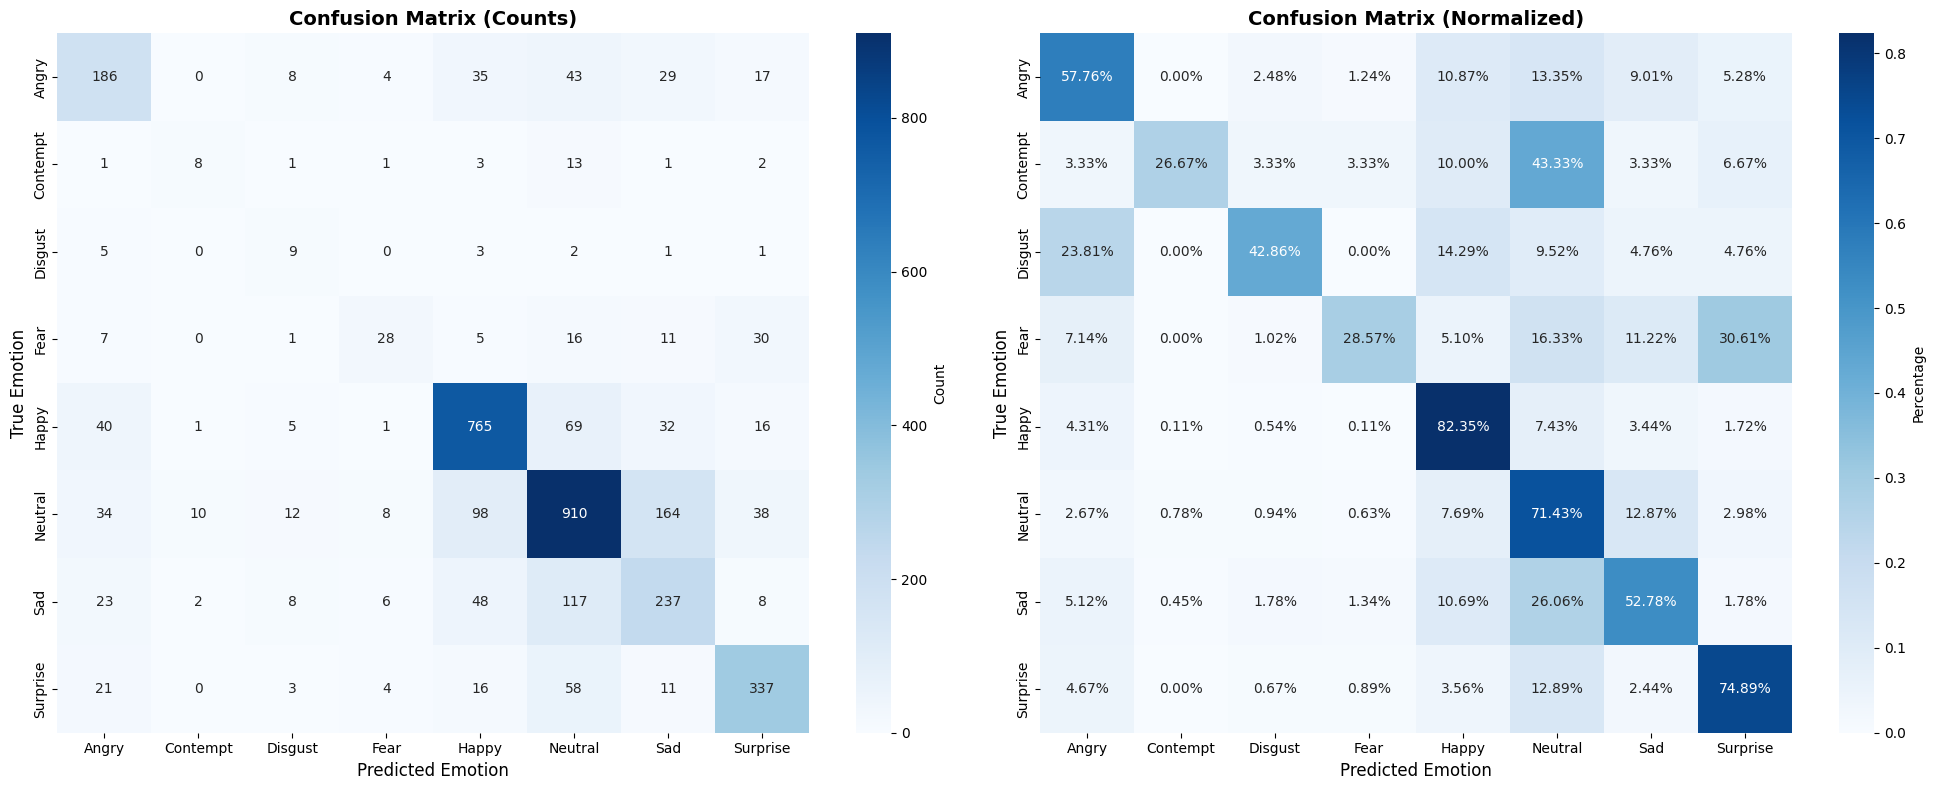

✅ Confusion matrix saved to /Users/nadaashraf/Desktop/FER copy/outputs/confusion_matrix.png


In [7]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Absolute counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=EMOTIONS, yticklabels=EMOTIONS,
    cbar_kws={'label': 'Count'},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Emotion', fontsize=12)
axes[0].set_ylabel('True Emotion', fontsize=12)

# Normalized (percentages)
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=EMOTIONS, yticklabels=EMOTIONS,
    cbar_kws={'label': 'Percentage'},
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion', fontsize=12)
axes[1].set_ylabel('True Emotion', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Confusion matrix saved to {OUTPUT_DIR / "confusion_matrix.png"}')

## Classification Report

In [8]:
# Generate classification report
report = classification_report(y_true, y_pred, target_names=EMOTIONS, output_dict=True)

# Convert to DataFrame for better display
report_df = pd.DataFrame(report).transpose()

print('\n📊 Classification Report:\n')
print(report_df.to_string())

# Save to CSV
report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')
print(f'\n✅ Classification report saved to {OUTPUT_DIR / "classification_report.csv"}')


📊 Classification Report:

              precision    recall  f1-score      support
Angry          0.586751  0.577640  0.582160   322.000000
Contempt       0.380952  0.266667  0.313725    30.000000
Disgust        0.191489  0.428571  0.264706    21.000000
Fear           0.538462  0.285714  0.373333    98.000000
Happy          0.786228  0.823466  0.804416   929.000000
Neutral        0.741042  0.714286  0.727418  1274.000000
Sad            0.487654  0.527840  0.506952   449.000000
Surprise       0.750557  0.748889  0.749722   450.000000
accuracy       0.694095  0.694095  0.694095     0.694095
macro avg      0.557892  0.546634  0.540304  3573.000000
weighted avg   0.696433  0.694095  0.693547  3573.000000

✅ Classification report saved to /Users/nadaashraf/Desktop/FER copy/outputs/classification_report.csv


## Per-Class Performance Visualization


Per-Class Metrics:
 Emotion  Precision   Recall  F1-Score  Support
   Angry   0.586751 0.577640  0.582160      322
Contempt   0.380952 0.266667  0.313725       30
 Disgust   0.191489 0.428571  0.264706       21
    Fear   0.538462 0.285714  0.373333       98
   Happy   0.786228 0.823466  0.804416      929
 Neutral   0.741042 0.714286  0.727418     1274
     Sad   0.487654 0.527840  0.506952      449
Surprise   0.750557 0.748889  0.749722      450


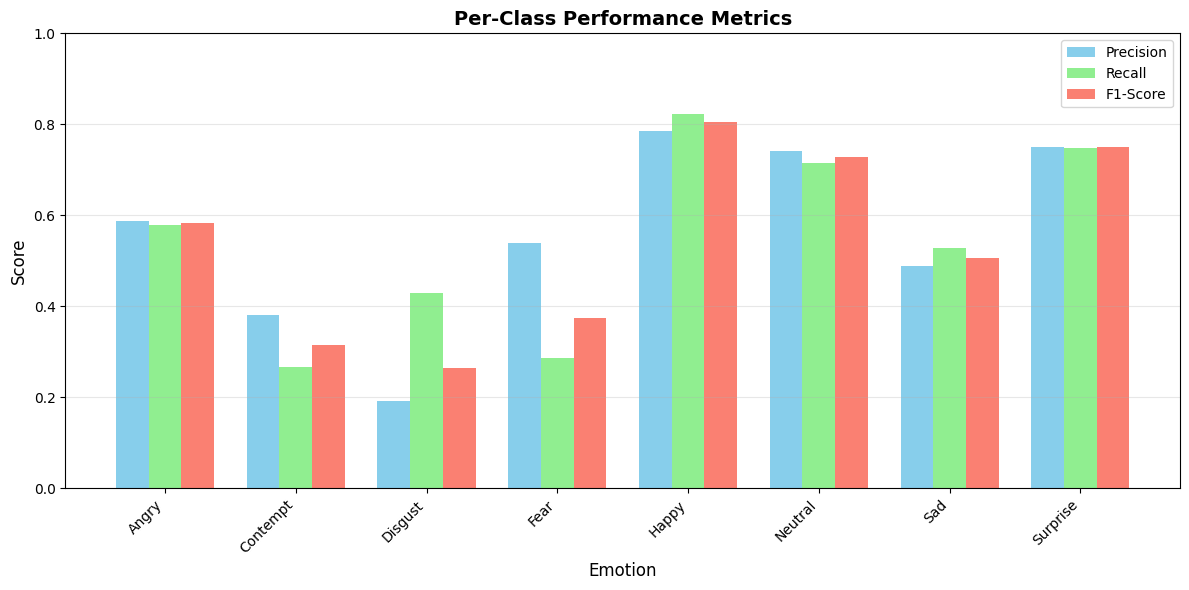


✅ Per-class metrics plot saved to /Users/nadaashraf/Desktop/FER copy/outputs/per_class_metrics.png


In [9]:
# Extract per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Emotion': EMOTIONS,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print('\nPer-Class Metrics:')
print(metrics_df.to_string(index=False))

# Visualize metrics
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(EMOTIONS))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
bars2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='salmon')

ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Per-class metrics plot saved to {OUTPUT_DIR / "per_class_metrics.png"}')

## Error Analysis

In [10]:
# Find misclassified samples
misclassified_indices = np.where(y_true != y_pred)[0]
total_misclassified = len(misclassified_indices)

print(f'\n🔍 Error Analysis:')
print(f'Total misclassified: {total_misclassified} / {len(y_true)} ({total_misclassified/len(y_true)*100:.2f}%)')

# Analyze common misclassifications
print('\nMost Common Misclassifications:')
misclass_pairs = {}
for idx in misclassified_indices:
    true_label = EMOTIONS[y_true[idx]]
    pred_label = EMOTIONS[y_pred[idx]]
    pair = f'{true_label} → {pred_label}'
    misclass_pairs[pair] = misclass_pairs.get(pair, 0) + 1

# Sort by frequency
sorted_pairs = sorted(misclass_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

for pair, count in sorted_pairs:
    print(f'{pair}: {count} times')


🔍 Error Analysis:
Total misclassified: 1093 / 3573 (30.59%)

Most Common Misclassifications:
Neutral → Sad: 164 times
Sad → Neutral: 117 times
Neutral → Happy: 98 times
Happy → Neutral: 69 times
Surprise → Neutral: 58 times
Sad → Happy: 48 times
Angry → Neutral: 43 times
Happy → Angry: 40 times
Neutral → Surprise: 38 times
Angry → Happy: 35 times


## Visualize Misclassified Examples

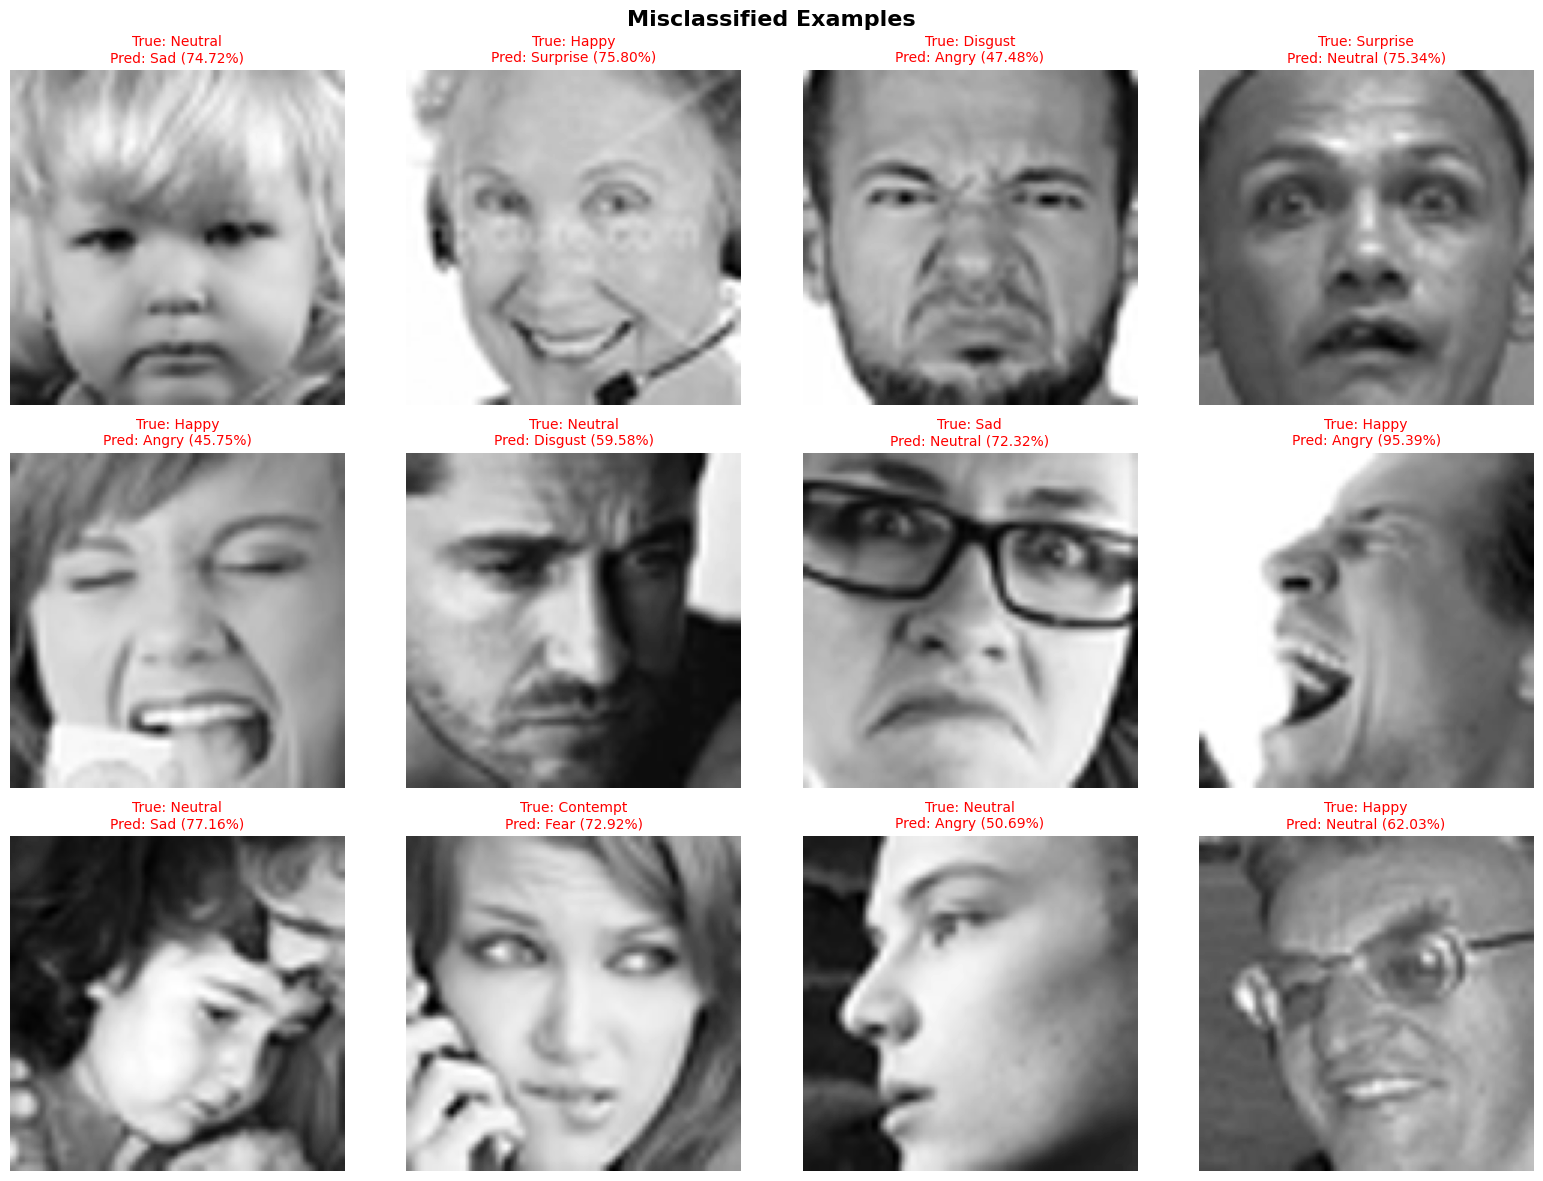

✅ Misclassified examples saved to /Users/nadaashraf/Desktop/FER copy/outputs/misclassified_examples.png


In [11]:
# Get file paths for misclassified images
test_files = test_generator.filenames

# Show some misclassified examples
num_examples = min(12, len(misclassified_indices))
sample_indices = np.random.choice(misclassified_indices, num_examples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, idx in enumerate(sample_indices):
    # Load and display image
    img_path = DATA_DIR / 'test' / test_files[idx]
    img = plt.imread(img_path)
    
    true_emotion = EMOTIONS[y_true[idx]]
    pred_emotion = EMOTIONS[y_pred[idx]]
    confidence = predictions[idx][y_pred[idx]]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f'True: {true_emotion}\nPred: {pred_emotion} ({confidence:.2%})',
        fontsize=10,
        color='red'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Misclassified examples saved to {OUTPUT_DIR / "misclassified_examples.png"}')

## Save Evaluation Results

In [12]:
# Compile evaluation results
evaluation_results = {
    'model_path': str(MODEL_PATH),
    'test_accuracy': float(test_accuracy),
    'total_samples': int(len(y_true)),
    'misclassified': int(total_misclassified),
    'per_class_metrics': {
        emotion: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1_score': float(f1[i]),
            'support': int(support[i])
        }
        for i, emotion in enumerate(EMOTIONS)
    },
    'confusion_matrix': cm.tolist(),
    'common_misclassifications': sorted_pairs[:5]
}

with open(OUTPUT_DIR / 'evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f'\n✅ Evaluation results saved to {OUTPUT_DIR / "evaluation_results.json"}')


✅ Evaluation results saved to /Users/nadaashraf/Desktop/FER copy/outputs/evaluation_results.json


## Summary

**Evaluation Complete!**

**Generated Outputs:**
- ✅ Confusion matrix (counts and normalized)
- ✅ Classification report (CSV)
- ✅ Per-class metrics visualization
- ✅ Misclassified examples
- ✅ Evaluation results (JSON)

**Key Metrics:**
- Test Accuracy
- Per-class Precision, Recall, F1-scores
- Error analysis with common misclassifications

**Next Steps:**
- Review confusion matrix for class confusions
- Analyze which emotions are hardest to classify
- Use insights to improve model in Phase 2